# Al 金属收敛交互教程
Metallic k-Point Sampling and Cold Smearing

先完成 Al 截断能案例，知道 SCF、平面波与化学势。
本课读取 12 组真实集群日志，学习同展宽比较、联合阈值和不能证明的极限。
无需集群连接。不求声子、EPC 或 Tc，也不做零宽外推。

## 1. 先读实验计划
预测：哪一种 σ 会更需要密 k 网格？请先写理由，再看结果。

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collect_results import collect, summarize, RY_TO_MEV
root = Path.cwd()
plan = json.loads((root/"scan_plan.json").read_text(encoding="utf-8"))
print("Cases:", len(plan["cases"]))
print("Fixed:", plan["fixed_parameters"])
print("Predeclared thresholds:", plan["thresholds"])
assert len(plan["cases"]) == 12

Cases: 12
Fixed: {'ecutwfc_Ry': 60, 'ecutrho_Ry': 640, 'celldm1_bohr': 7.65339, 'nat': 1, 'nbnd': 6, 'smearing': 'mv', 'conv_thr_Ry': 1e-10, 'k_shift': [1, 1, 1], 'pseudopotential': 'Al.pbe-n-kjpaw_psl.1.0.0.UPF'}
Predeclared thresholds: {'energy_meV_per_atom': 0.1, 'pressure_kbar': 0.1, 'fermi_eV': 0.005}


## 2. 从原始输出重新解析
哈希与参数一致时才沿用归档作业号。缺失一组时不将部分数据称为完整扫描。

In [2]:
report = collect(root)
archived = json.loads((root/"results/validation.json").read_text(encoding="utf-8"))
assert report["sigma_summaries"] == archived["sigma_summaries"]
print("JobID:", report["job_id"])
print("Common tested k candidate:", report["common_tested_k"])
for summary in report["sigma_summaries"]:
    print(summary)

JobID: 313714
Common tested k candidate: None
{'degauss_Ry': 0.02, 'reference_k': 20, 'lowest_joint_acceptable_k': None}
{'degauss_Ry': 0.01, 'reference_k': 20, 'lowest_joint_acceptable_k': None}
{'degauss_Ry': 0.005, 'reference_k': 20, 'lowest_joint_acceptable_k': None}


## 3. 只在相同 σ 内比较 k
每条曲线的参考是同 σ 的 20³，不是所有 σ 共用一条能量。
参考自己的差为 0 是定义，不是无限网格误差为 0。

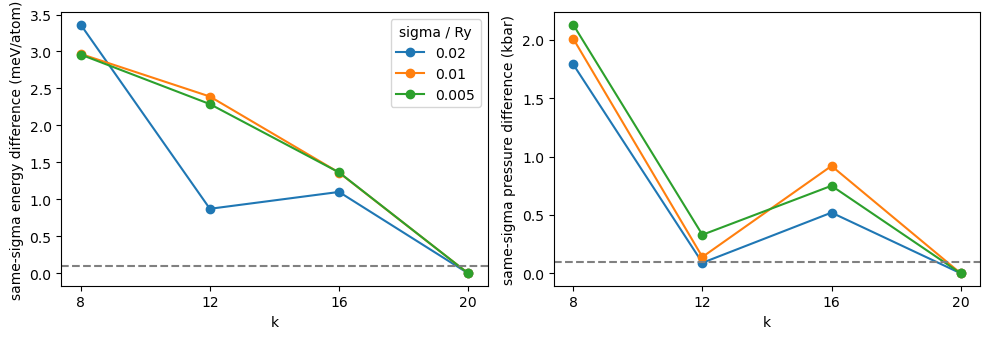

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for sigma in [0.02, 0.01, 0.005]:
    rows = [r for r in report["rows"] if r["degauss_Ry"] == sigma]
    x = [r["k_mesh"] for r in rows]
    axes[0].plot(x, [r["abs_energy_difference_meV_per_atom"] for r in rows], "o-", label=str(sigma))
    axes[1].plot(x, [abs(r["pressure_difference_kbar"]) for r in rows], "o-", label=str(sigma))
axes[0].axhline(0.1, ls="--", color="gray")
axes[1].axhline(0.1, ls="--", color="gray")
axes[0].set(xlabel="k", ylabel="same-sigma energy difference (meV/atom)")
axes[1].set(xlabel="k", ylabel="same-sigma pressure difference (kbar)")
for ax in axes:
    ax.set_xticks([8, 12, 16, 20])
axes[0].legend(title="sigma / Ry")
plt.tight_layout(); plt.show()

## 4. 检查能量定义
确认 E=F−C，其中 C 是输出的 smearing contribution (-TS)。这是代数核对，不是零温外推。

In [4]:
identity_errors = [abs(r["internal_energy_Ry"]-(r["energy_Ry"]-r["minus_TS_Ry"]))
                   for r in report["rows"]]
print("max printed-identity residual (Ry):", max(identity_errors))
assert max(identity_errors) < 2.1e-8
example = report["rows"][0]
print("Example F, C, E:", example["energy_Ry"], example["minus_TS_Ry"], example["internal_energy_Ry"])
print("0.005 Ry in eV:", 0.005*RY_TO_MEV/1000)

max printed-identity residual (Ry): 1.000000082740371e-08
Example F, C, E: -39.5030599 4.08e-05 -39.5031007
0.005 Ry in eV: 0.06802846561497


## 5. 改阈值是敏感性实验
仅放宽能量标准不一定改变联合候选，因为压力/Fermi energy 也可能失败。
以下不会覆盖归档报告。请解释每个改变，而不是挑一个看起来最便宜的设置。

In [5]:
for energy_target in [0.1, 0.5, 1.0]:
    thresholds = {**report["thresholds"], "energy_meV_per_atom": energy_target}
    trial = summarize(report["rows"], thresholds)
    print("Energy target:", energy_target, "meV/atom")
    print("Same pressure/Fermi targets:", trial["common_tested_k"])
    print([s["lowest_joint_acceptable_k"] for s in trial["sigma_summaries"]])
print("Archival thresholds remain:", archived["thresholds"])

Energy target: 0.1 meV/atom
Same pressure/Fermi targets: None
[None, None, None]
Energy target: 0.5 meV/atom
Same pressure/Fermi targets: None
[None, None, None]
Energy target: 1.0 meV/atom
Same pressure/Fermi targets: None
[None, None, None]
Archival thresholds remain: {'energy_meV_per_atom': 0.1, 'pressure_kbar': 0.1, 'fermi_eV': 0.005}


## 6. 固定 k 看 σ，而不宣称零温
判断跨 σ 敏感性前，先问该 k 对每个 σ 是否已被证明足够。
如果联合候选为空，不能跳过此问题把最窄 σ 称为可靠结果。

In [6]:
rows = sorted([r for r in report["rows"] if r["k_mesh"] == report["reference_k"]],
              key=lambda r: r["degauss_Ry"])
for r in rows:
    print("sigma:", r["degauss_Ry"], "F:", r["energy_Ry"],
          "P:", r["pressure_kbar"], "Ef:", r["fermi_eV"])
print("Sensitivity (NOT a zero-width error estimate):")
print(report["sigma_sensitivity_at_max_k"])
assert report["sigma_sensitivity_at_max_k"]["is_zero_smearing_error_estimate"] is False

sigma: 0.005 F: -39.50284078 P: -6.07 Ef: 7.8513
sigma: 0.01 F: -39.50283347 P: -6.33 Ef: 7.8494
sigma: 0.02 F: -39.5028128 P: -6.34 Ef: 7.8473
Sensitivity (NOT a zero-width error estimate):
{'energy_span_meV_per_atom': 0.3806872935637699, 'internal_energy_span_meV_per_atom': 0.29184211756345463, 'pressure_span_kbar': 0.2699999999999996, 'fermi_span_eV': 0.004000000000000448, 'is_zero_smearing_error_estimate': False}


## 独立练习
1. 找出一个总能/压力/Fermi energy 不同程度变化的案例，手算误差。
2. 解释为什么 20³ 的差为 0 却不能单独证明收敛。
3. 修改本 Notebook 的能量阈值，但保留其他阈值；写出是否改变候选及原因。
4. 写出接下来应补的网格、展宽或截断能证据，不直接跳到 Tc。

答案提示见同目录中文教程。本 Notebook 与课件是原创学习实验，
并不是某篇原始研究图表的定量复现。